In [1]:
%reset -f

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from atstaging.dataorg.utils import add_features_by_date, load_csv_by_match
from atstaging.config import get, set_config
from atstaging.outputs import load_split
from atstaging.preprocessing.bids import ATPreprocMRINamer

set_config('main')

master = load_split(None, None, verbose=False)
master = master[['Subject', 'Session', 'TauAmyloidMeanDate', 'DataSet', 'Split', 'ControlForStaging', 'CDRBinned']].copy()


----- ATSTAGING CONFIG -----
Using configuration: main.json
----------------------------


In [44]:
# A4
path_a4_raw = '/home/tom.earnest/a4_clinical/RawData/'
a4_basedate = pd.Timestamp(year=2001, month=1, day=1)

# ADNI
path_adni_neurobat = '/home/tom.earnest/adni_clinical/neurobat.csv'
path_adni_adas = '/home/tom.earnest/adni_clinical/adas.csv'

# GS1
path_gs1_ques = '/ceph/chpc/shared/aristeidis_sotiras_group/aris_data/GS1/tabular/raw_sdtm/csv/questionnaires.csv'

# GS2
path_gs2_ques = '/ceph/chpc/shared/aristeidis_sotiras_group/aris_data/GS2/tabular/raw_sdtm/csv/questionnaires.csv'

# HABS
path_habs_clinical = '/ceph/chpc/shared/aristeidis_sotiras_group/aris_data/HABS/tabular/Cognition_HABS_DataRelease_2.0.csv'

# HABS-HD
path_habshd_tabular = '/ceph/chpc/shared/aristeidis_sotiras_group/aris_data/HABS-HD/tabular/'
path_habshd_mri_search = '/scratch/tom.earnest/atstaging/searches/habshd_t1_10102024_12_05_2024.csv'

# OASIS
path_oasis_cog = '/home/tom.earnest/OASIS3_data_files/scans/pychometrics-Form_C1__Cognitive_Assessments/resources/csv/files/OASIS3_UDSc1_cognitive_assessments.csv'
oasis_basedate = pd.Timestamp(year=2001, month=1, day=1)

# SCAN
path_scan_dataset = '/ceph/chpc/shared/aristeidis_sotiras_group/aris_data/NACC_SCAN/tabular/investigator_nacc66_atsubset.csv'

# Helper funcs

In [4]:
def calculate_pacc(df, columns, cn_mask, min_required=2, higher_better=None, verbose=False):

    vprint = print if verbose else lambda *args, **kwargs: None
    
    cn = df[cn_mask].copy()
    n = len(df)
    k = len(columns)

    normed_scores = pd.DataFrame(np.full((n, k), np.nan))
    normed_scores.columns = columns
    normed_scores.index = df.index
    
    if higher_better is None:
        higher_better = [True] * k

    vprint('')
    for i in range(k):
        col = columns[i]
        mu = cn[col].mean()
        s = cn[col].std()
        z = (df[col] - mu) / s

        vprint(f'{col}: mean={mu}, std={s}')

        if not higher_better[i]:
            z *= -1

        normed_scores[col] = z

    score = np.nansum(normed_scores, axis=1)
    count_present = (~normed_scores.isna()).sum(axis=1)
    score[count_present < min_required] = np.nan

    return score

def nps_composites(
    data,
    cn_mask,
    mem_cols=None,
    mem_higher_better=None,
    exf_cols=None,
    exf_higher_better=None,
    lan_cols=None,
    lan_higher_better=None,
    vsp_cols=None,
    vsp_higher_better=None,
    plot=True,
    mem_min_required=1,
    exf_min_required=1,
    lan_min_required=1,
    vsp_min_required=1,
):

    if mem_cols is None:
        mem = np.nan
    else:
        mem = calculate_pacc(df=data, columns=mem_cols, cn_mask=cn_mask, min_required=mem_min_required, higher_better=mem_higher_better)

    if exf_cols is None:
        exf = np.nan
    else:
        exf = calculate_pacc(df=data, columns=exf_cols, cn_mask=cn_mask, min_required=exf_min_required, higher_better=exf_higher_better)

    if lan_cols is None:
        lan = np.nan
    else:
        lan = calculate_pacc(df=data, columns=lan_cols, cn_mask=cn_mask, min_required=lan_min_required, higher_better=lan_higher_better)

    if vsp_cols is None:
        vsp = None
    else:
        vsp = calculate_pacc(df=data, columns=vsp_cols, cn_mask=cn_mask, min_required=vsp_min_required, higher_better=vsp_higher_better)

    result = data[['Subject', 'Session']].copy()
    result['CompositeMEM'] = mem
    result['CompositeEXF'] = exf
    result['CompositeLAN'] = lan
    result['CompositeVSP'] = vsp

    if plot:
        tmp = result.copy()
        tmp['CDR'] = data['CDRBinned']
        tmp = tmp.melt(id_vars=['CDR'], value_vars=['CompositeMEM', 'CompositeEXF', 'CompositeLAN', 'CompositeVSP'])
        plt.figure()
        sns.boxplot(tmp, x='variable', y='value', hue='CDR', hue_order=['0.0', '0.5', '1.0+'])
        plt.xticks(rotation=45, ha='right')

    return result

# A4

In [60]:
# LOAD THE DATA
# -------------

digit = load_csv_by_match(directory=path_a4_raw, pattern='cogdigit')
logimem = load_csv_by_match(directory=path_a4_raw, pattern='coglogic')
fcsr = load_csv_by_match(directory=path_a4_raw, pattern='cogfcsr')

def add_a4_table(master, other, fields):
    other = other[other['VISCODE'].lt(700)].copy()
    other['Date'] = a4_basedate +  pd.to_timedelta(other['VISCODE'], unit='W')
    master = add_features_by_date(master, other, fields=fields,
                                  a_subject='Subject', a_date='TauAmyloidMeanDate',
                                  b_subject='BID', b_date='Date', include_gap_cols=False)
    return master

master_a4 = master[master['DataSet'].eq('A4')].copy()
master_a4 = add_a4_table(master_a4, digit, ['DIGITTOTAL'])
master_a4 = add_a4_table(master_a4, logimem, ['LIMMTOTAL', 'LDELTOTAL'])
master_a4 = add_a4_table(master_a4, fcsr, ['FCTOTF', 'FCTOTC'])
master_a4['FCSRTTotal'] = master_a4['FCTOTF'] + master_a4['FCTOTC']

([0, 1, 2, 3],
 [Text(0, 0, 'DIGITTOTAL'),
  Text(1, 0, 'LIMMTOTAL'),
  Text(2, 0, 'LDELTOTAL'),
  Text(3, 0, 'FCSRTTotal')])

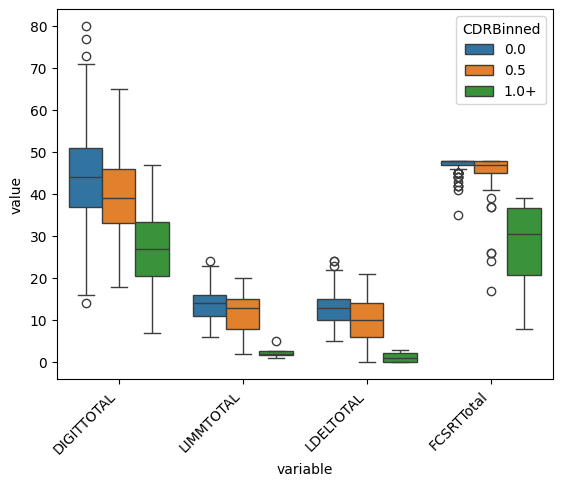

In [62]:
# PLOT INDVL ASSESSMENTS
# -------------

assessments = [
    'DIGITTOTAL', 'LIMMTOTAL', 'LDELTOTAL', 'FCSRTTotal'
]
pdata = master_a4.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

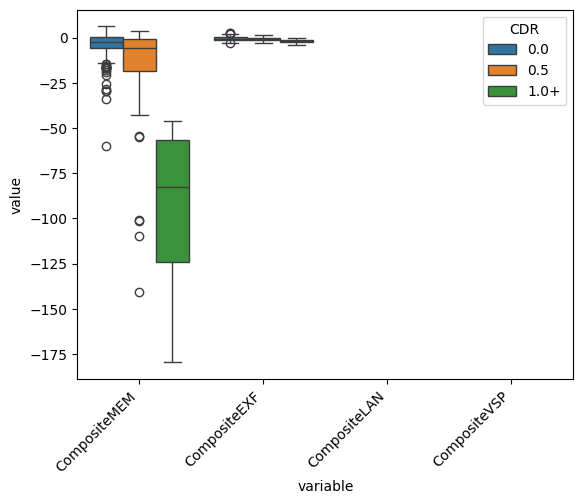

In [63]:
# COMPUTE COMPOSITES
# -------------

mem_cols = ['LIMMTOTAL', 'LDELTOTAL', 'FCSRTTotal']
mem_higher_better = [True, True, True]
exf_cols = ['DIGITTOTAL']
exf_higher_better = [True]
lan_cols = None
lan_higher_better = None
vsp_cols = None
vsp_higher_better = None

a4_nps = nps_composites(
    data=master_a4,
    cn_mask=master_a4['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

# ADNI

In [5]:
# LOAD THE DATA
# -------------

master_adni = master[master['DataSet'].eq('ADNI')].copy()
neurobat = pd.read_csv(path_adni_neurobat)
adas = pd.read_csv(path_adni_adas)

# Neurobat
neurobat['Subject'] = neurobat['PTID'].str.replace('_', '')
merger1 = neurobat[[
    'Subject',
    'VISDATE',
    'AVTOT1', 'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5',
    'AVDEL30MIN',
    'LIMMTOTAL',
    'LDELTOTAL',
    'DSPANFOR',
    'DSPANBAC',
    'DIGITSCOR',
    'TRAASCOR',
    'TRABSCOR',
    'BNTTOTAL',
    'CATANIMSC',
    'CATVEGESC',
    'MINTTOTAL',
    'CLOCKSCOR',
]].copy()
merger1['AVIMMEDIATE'] = merger1[['AVTOT1', 'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5']].sum(axis=1)
merger1.loc[merger1['AVTOT1'].isna(), 'AVIMMEDIATE'] = np.nan

# ADAS
adas['Subject'] = adas['PTID'].str.replace('_', '')
merger2 = adas[['Subject', "EXAMDATE", 'Q3SCORE', 'Q5SCORE']]

# merge
master_adni = add_features_by_date(master_adni, merger1, fields=[col for col in merger1.columns if col not in ['Subject', 'VISDATE']],
                                   a_subject='Subject', a_date='TauAmyloidMeanDate', b_subject='Subject', b_date='VISDATE', include_gap_cols=False)
master_adni = add_features_by_date(master_adni, merger2, fields=['Q3SCORE', 'Q5SCORE'],
                                   a_subject='Subject', a_date='TauAmyloidMeanDate', b_subject='Subject', b_date='EXAMDATE', include_gap_cols=False)

/tmp/ipykernel_2025479/4196272387.py:5: DtypeWarning: Columns (79,80) have mixed types. Specify dtype option on import or set low_memory=False.
  neurobat = pd.read_csv(path_adni_neurobat)
/tmp/ipykernel_2025479/4196272387.py:6: DtypeWarning: Columns (135,136,137,138,142,143,144,145,146,147,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,210) have mixed types. Specify dtype option on import or set low_memory=False.
  adas = pd.read_csv(path_adni_adas)
/home/tom.earnest/code/at_nmf_sustain/atstaging/dataorg/utils.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'AVDEL30MIN'),
  Text(1, 0, 'LIMMTOTAL'),
  Text(2, 0, 'LDELTOTAL'),
  Text(3, 0, 'DSPANFOR'),
  Text(4, 0, 'DSPANBAC'),
  Text(5, 0, 'DIGITSCOR'),
  Text(6, 0, 'TRAASCOR'),
  Text(7, 0, 'TRABSCOR'),
  Text(8, 0, 'BNTTOTAL'),
  Text(9, 0, 'CATANIMSC'),
  Text(10, 0, 'CATVEGESC'),
  Text(11, 0, 'MINTTOTAL'),
  Text(12, 0, 'CLOCKSCOR'),
  Text(13, 0, 'AVIMMEDIATE'),
  Text(14, 0, 'Q3SCORE'),
  Text(15, 0, 'Q5SCORE')])

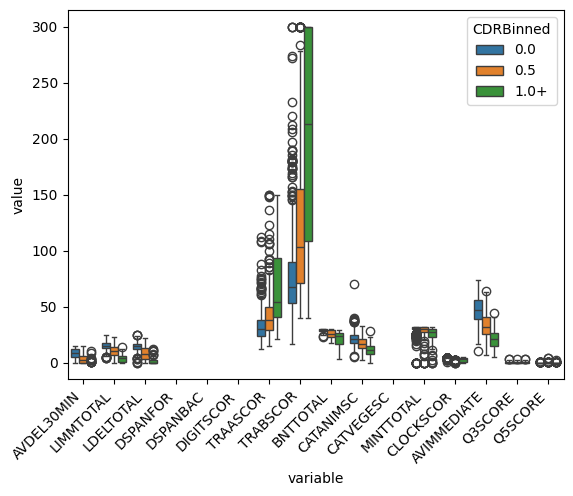

In [6]:
# PLOT INDVL ASSESSMENTS
# -------------

assessments = [
    'AVDEL30MIN',
    'LIMMTOTAL',
    'LDELTOTAL',
    'DSPANFOR',
    'DSPANBAC',
    'DIGITSCOR',
    'TRAASCOR',
    'TRABSCOR',
    'BNTTOTAL',
    'CATANIMSC',
    'CATVEGESC',
    'MINTTOTAL',
    'CLOCKSCOR',
    'AVIMMEDIATE',
    'Q3SCORE',
    'Q5SCORE'
]
pdata = master_adni.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

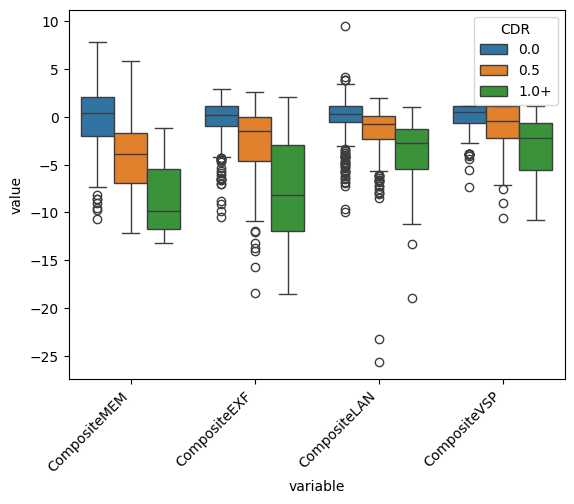

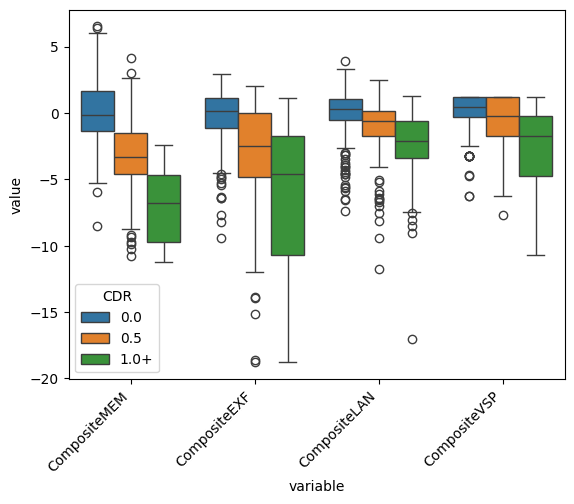

In [7]:
# COMPUTE COMPOSITES
# -------------

mem_cols = ['AVIMMEDIATE', 'AVDEL30MIN', 'LIMMTOTAL', 'LDELTOTAL']
mem_higher_better = [True, True, True, True]
exf_cols = ['TRAASCOR', 'TRABSCOR']
exf_higher_better = [False, False]
lan_cols = ['BNTTOTAL', 'CATANIMSC', 'MINTTOTAL', 'Q5SCORE']
lan_higher_better = [True, True, True, False]
vsp_cols = ['CLOCKSCOR', 'Q3SCORE']
vsp_higher_better = [True, False]

master_adni_train = master_adni[master_adni['Split'].str.contains('Training')].copy()
master_adni_validation = master_adni[master_adni['Split'].str.contains('Validation')].copy()

result_train = nps_composites(
    data=master_adni_train,
    cn_mask=master_adni_train['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

result_validation = nps_composites(
    data=master_adni_validation,
    cn_mask=master_adni_validation['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

adni_nps = pd.concat([result_train, result_validation], axis=0, ignore_index=True)

# GS1

In [8]:
ques = pd.read_csv(path_gs1_ques)

/tmp/ipykernel_2025479/252504996.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  ques = pd.read_csv(path_gs1_ques)


In [9]:
# LOAD THE DATA
# -------------

master_gs1 = master[master['DataSet'].eq('GS1')].copy()

rbans_domains =  ['RBANS-Immediate Memory', 'RBANS-Delayed Memory', 'RBANS-Visuospatial/Constructional', 'RBANS-Language', 'RBANS-Attention']
rbans = ques.loc[ques['Question Name'].isin(rbans_domains),  ['Subject Identifier for the Study', 'Date/Time of Finding', 'Question Name', 'Finding in Original Units']]
rbans = rbans.sort_values(['Subject Identifier for the Study', 'Date/Time of Finding']).reset_index(drop=True)
rbans = rbans[rbans['Finding in Original Units'].ne('NOT APPLICABLE')].copy()
rbans = rbans.drop_duplicates(['Subject Identifier for the Study', 'Date/Time of Finding', 'Question Name'])
rbans['Finding in Original Units'] = rbans['Finding in Original Units'].astype(float)

wide = rbans.pivot(index=['Subject Identifier for the Study', 'Date/Time of Finding'], columns='Question Name', values='Finding in Original Units')
wide = wide.reset_index()
wide['Subject'] = 'S' + wide['Subject Identifier for the Study'].astype(str)

master_gs1 = add_features_by_date(master_gs1, wide, fields=['RBANS-Immediate Memory', 'RBANS-Delayed Memory', 'RBANS-Visuospatial/Constructional', 'RBANS-Language', 'RBANS-Attention'],
                                  a_subject='Subject', a_date='TauAmyloidMeanDate', b_subject='Subject', b_date='Date/Time of Finding', include_gap_cols=False)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'RBANS-Immediate Memory'),
  Text(1, 0, 'RBANS-Delayed Memory'),
  Text(2, 0, 'RBANS-Visuospatial/Constructional'),
  Text(3, 0, 'RBANS-Language'),
  Text(4, 0, 'RBANS-Attention')])

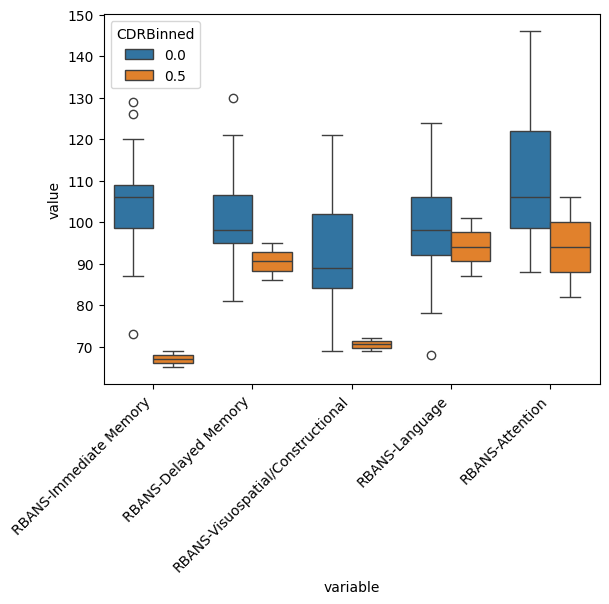

In [10]:
# PLOT INDVL ASSESSMENTS
# -------------

assessments = ['RBANS-Immediate Memory', 'RBANS-Delayed Memory', 'RBANS-Visuospatial/Constructional', 'RBANS-Language', 'RBANS-Attention']
pdata = master_gs1.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

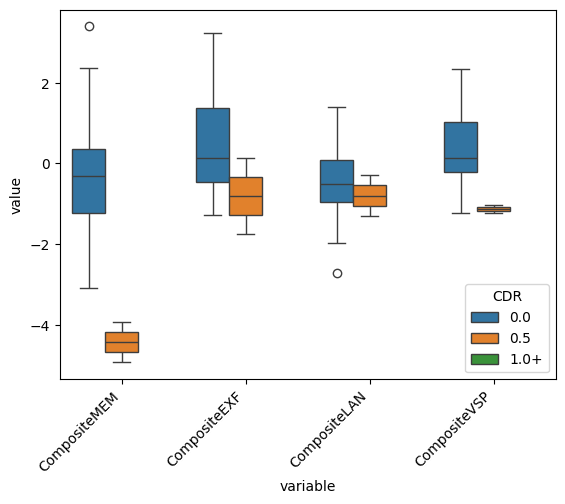

In [11]:
# COMPUTE COMPOSITES
# -------------

mem_cols = ['RBANS-Immediate Memory', 'RBANS-Delayed Memory']
mem_higher_better = [True, True]
exf_cols = ['RBANS-Attention']
exf_higher_better = [True]
lan_cols = ['RBANS-Language']
lan_higher_better = [True]
vsp_cols = ['RBANS-Visuospatial/Constructional']
vsp_higher_better = [True]

gs1_nps = nps_composites(
    data=master_gs1,
    cn_mask=master_gs1['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

# GS2

In [12]:
ques = pd.read_csv(path_gs2_ques)

/tmp/ipykernel_2025479/304154809.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  ques = pd.read_csv(path_gs2_ques)


In [13]:
# LOAD THE DATA
# -------------

master_gs2 = master[master['DataSet'].eq('GS2')].copy()

rbans_domains =  ['RBANS-Immediate Memory', 'RBANS-Delayed Memory', 'RBANS-Visuospatial/Constructional', 'RBANS-Language', 'RBANS-Attention']
rbans = ques.loc[ques['Question Name'].isin(rbans_domains),  ['Subject Identifier for the Study', 'Date/Time of Finding', 'Question Name', 'Finding in Original Units']]
rbans = rbans.sort_values(['Subject Identifier for the Study', 'Date/Time of Finding']).reset_index(drop=True)
rbans = rbans[rbans['Finding in Original Units'].ne('NOT APPLICABLE')].copy()
rbans = rbans.drop_duplicates(['Subject Identifier for the Study', 'Date/Time of Finding', 'Question Name'])
rbans['Finding in Original Units'] = rbans['Finding in Original Units'].astype(float)

wide = rbans.pivot(index=['Subject Identifier for the Study', 'Date/Time of Finding'], columns='Question Name', values='Finding in Original Units')
wide = wide.reset_index()
wide['Subject'] = 'S' + wide['Subject Identifier for the Study'].astype(str)

master_gs2 = add_features_by_date(master_gs2, wide, fields=['RBANS-Immediate Memory', 'RBANS-Delayed Memory', 'RBANS-Visuospatial/Constructional', 'RBANS-Language', 'RBANS-Attention'],
                                  a_subject='Subject', a_date='TauAmyloidMeanDate', b_subject='Subject', b_date='Date/Time of Finding', include_gap_cols=False)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'RBANS-Immediate Memory'),
  Text(1, 0, 'RBANS-Delayed Memory'),
  Text(2, 0, 'RBANS-Visuospatial/Constructional'),
  Text(3, 0, 'RBANS-Language'),
  Text(4, 0, 'RBANS-Attention')])

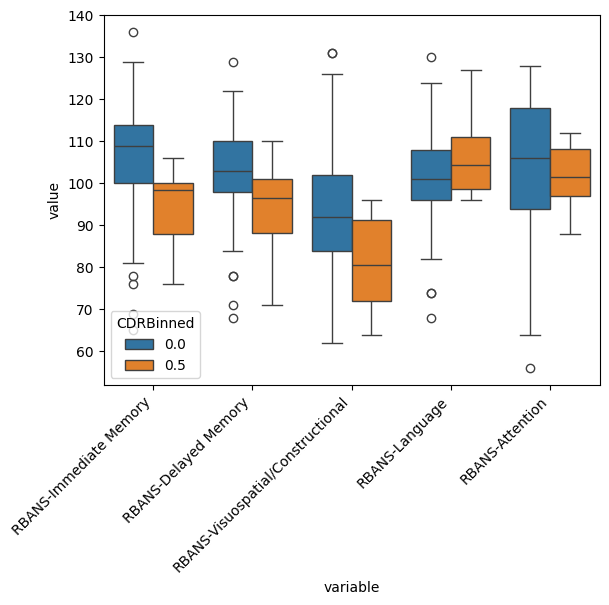

In [14]:
# PLOT INDVL ASSESSMENTS
# -------------

assessments = ['RBANS-Immediate Memory', 'RBANS-Delayed Memory', 'RBANS-Visuospatial/Constructional', 'RBANS-Language', 'RBANS-Attention']
pdata = master_gs2.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

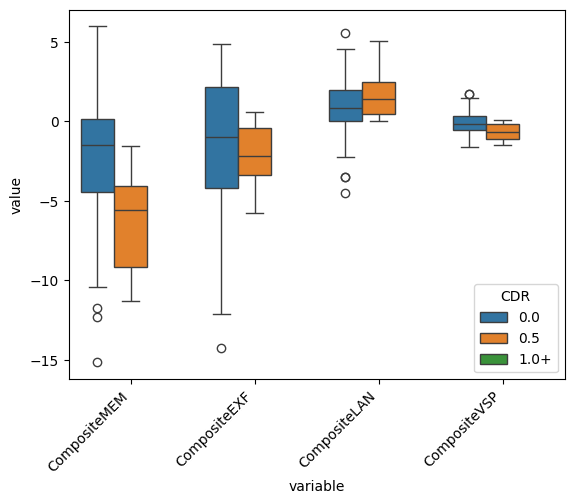

In [15]:
# COMPUTE COMPOSITES
# -------------

mem_cols = ['RBANS-Immediate Memory', 'RBANS-Delayed Memory']
mem_higher_better = [True, True]
exf_cols = ['RBANS-Attention']
exf_higher_better = [True]
lan_cols = ['RBANS-Language']
lan_higher_better = [True]
vsp_cols = ['RBANS-Visuospatial/Constructional']
vsp_higher_better = [True]

gs2_nps = nps_composites(
    data=master_gs2,
    cn_mask=master_gs2['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

# HABS

In [16]:
# LOAD THE DATA
# -------------

clinical = pd.read_csv(path_habs_clinical)

cols = [
    'BNT_30', 'CAT_Animal_Total', 'CAT_Vegetable_Total', 'CAT_Fruit_Total',
    'Digits_Forward', 'Digits_Backwards', 'DigitSym',
    'FCsrt_FNC', 'FCsrt_Free', 'LogicMem_IL', 'LogicMem_DR',
    'TMT_A', 'TMT_B', 'VFDT'
]
merger = clinical[['SubjIDshort', 'NP_SessionDate'] + cols].copy()
merger['Subject'] = merger['SubjIDshort'].str.replace('_', '')

master_habs = master[master['DataSet'].eq('HABS')].copy()
master_habs = add_features_by_date(master_habs, merger, fields=cols,
                                   a_subject='Subject', a_date='TauAmyloidMeanDate',
                                   b_subject='Subject', b_date='NP_SessionDate', include_gap_cols=False)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'BNT_30'),
  Text(1, 0, 'CAT_Animal_Total'),
  Text(2, 0, 'CAT_Vegetable_Total'),
  Text(3, 0, 'CAT_Fruit_Total'),
  Text(4, 0, 'Digits_Forward'),
  Text(5, 0, 'Digits_Backwards'),
  Text(6, 0, 'DigitSym'),
  Text(7, 0, 'FCsrt_FNC'),
  Text(8, 0, 'FCsrt_Free'),
  Text(9, 0, 'LogicMem_IL'),
  Text(10, 0, 'LogicMem_DR'),
  Text(11, 0, 'TMT_A'),
  Text(12, 0, 'TMT_B'),
  Text(13, 0, 'VFDT')])

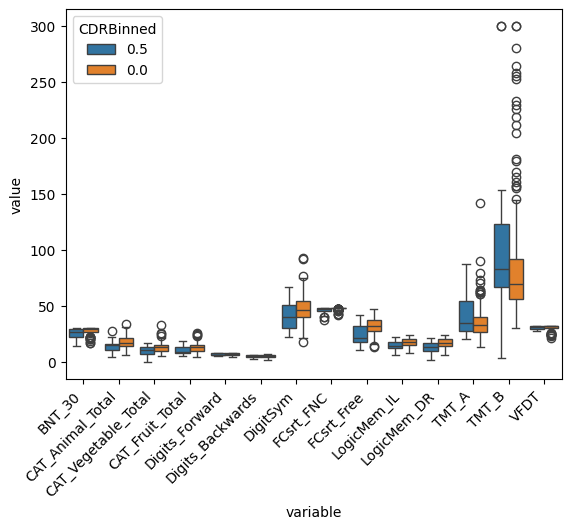

In [17]:
# PLOT INDVL ASSESSMENTS
# -------------

assessments = cols
pdata = master_habs.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

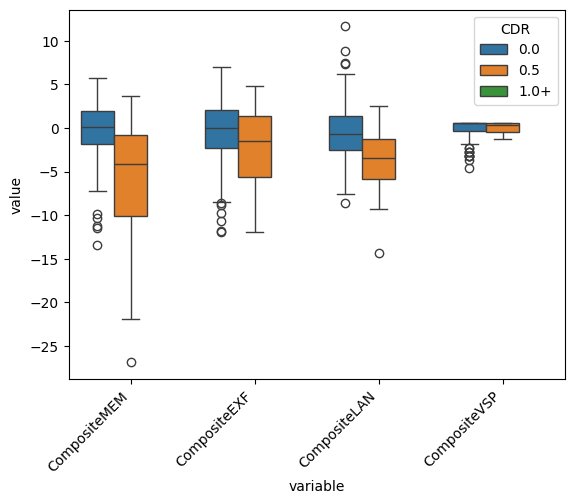

In [18]:
# COMPUTE COMPOSITES
# -------------

mem_cols = ['FCsrt_FNC', 'FCsrt_Free', 'LogicMem_IL', 'LogicMem_DR']
mem_higher_better = [True, True, True, True]
exf_cols = ['Digits_Forward', 'Digits_Backwards', 'DigitSym', 'TMT_A', 'TMT_B']
exf_higher_better = [True, True, True, False, False]
lan_cols = ['BNT_30', 'CAT_Animal_Total', 'CAT_Vegetable_Total', 'CAT_Fruit_Total']
lan_higher_better = [True, True, True, True]
vsp_cols = ['VFDT']
vsp_higher_better = [True]

habs_nps = nps_composites(
    data=master_habs,
    cn_mask=master_habs['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

# HABS-HD

In [29]:
tables = [
    'HD_1_African',
    'HD_1_Mexican',
    'HD_1_Non',
    'HD_2_Mexican',
    'HD_2_Non',
    'HD_3_Mexican',
    'HD_3_Non']
habshd = pd.concat([load_csv_by_match(path_habshd_tabular, t, dtype={'Med_ID': str}) for t in tables])
habshd = habshd.drop_duplicates(['Med_ID', 'Visit_ID'])

mri = pd.read_csv(path_habshd_mri_search, dtype={'Subject': str})

/home/tom.earnest/code/at_nmf_sustain/atstaging/dataorg/utils.py:371: DtypeWarning: Columns (10,11,24,26,70,110,137,139,147,705,707,718,728) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output, *args, **kwargs)
/home/tom.earnest/code/at_nmf_sustain/atstaging/dataorg/utils.py:371: DtypeWarning: Columns (10,11,24,25,26,27,70,114,116,118,120,137,139,147,705,707,715,728) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output, *args, **kwargs)


In [38]:
# LOAD THE DATA
# -------------

assessments = [
    # MEM
    'LM1_AB_Total',
    'LM2_AB_Total',

    # EXF
    'DSF_Total',
    'DSB_Total',
    'Digit_Symbol_Substitution',
    'Trails_A_Time',
    'Trails_B_Time',

    # LAN
    'FAS_Total',
    'Animal_Total',
    
    # VSP
]

master_habshd = master[master['DataSet'].eq('HABSHD')].copy()

# select habshd data to add
toadd = habshd[['Med_ID', 'Visit_ID'] + assessments]
toadd.columns = ['Subject', 'Visit'] + assessments

# get a date from the LONI MRI
linker = mri[['Subject', 'Visit', 'Acq Date']].copy()
linker.columns = ['Subject', 'Visit', 'Date']
linker['Visit'] = linker['Visit'].map({'Baseline': 1, 'Month 24 follow-up': 2, 'Month 48 follow-up': 3, 'Month 72 follow-up': 4})
toadd = toadd.merge(linker, on=['Subject', 'Visit'], how='left')

# merge into master
master_habshd = add_features_by_date(master_habshd, toadd, fields=assessments,
                                     a_subject='Subject', a_date='TauAmyloidMeanDate',
                                     b_subject='Subject', b_date='Date', include_gap_cols=False)
master_habshd[master_habshd.isin([-8888, -9999])] = np.nan

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'LM1_AB_Total'),
  Text(1, 0, 'LM2_AB_Total'),
  Text(2, 0, 'DSF_Total'),
  Text(3, 0, 'DSB_Total'),
  Text(4, 0, 'Digit_Symbol_Substitution'),
  Text(5, 0, 'Trails_A_Time'),
  Text(6, 0, 'Trails_B_Time'),
  Text(7, 0, 'FAS_Total'),
  Text(8, 0, 'Animal_Total')])

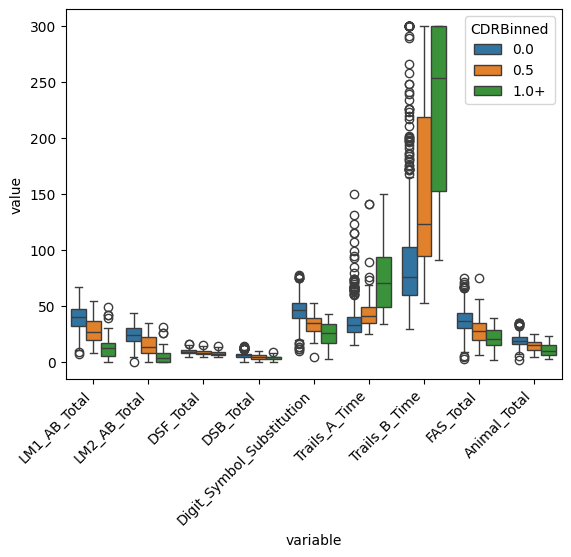

In [39]:
# PLOT INDVL ASSESSMENTS
# -------------

pdata = master_habshd.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

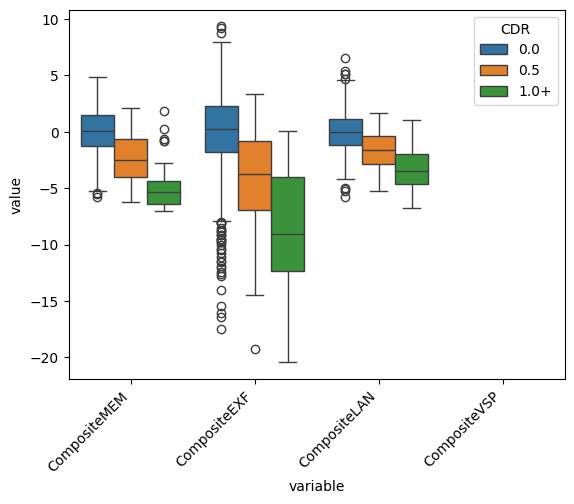

In [40]:
# COMPUTE COMPOSITES
# -------------

mem_cols = ['LM1_AB_Total', 'LM2_AB_Total']
mem_higher_better = [True, True]
exf_cols = ['DSF_Total', 'DSB_Total', 'Digit_Symbol_Substitution', 'Trails_A_Time', 'Trails_B_Time']
exf_higher_better = [True, True, True, False, False]
lan_cols = ['FAS_Total', 'Animal_Total']
lan_higher_better = [True, True]
vsp_cols = None
vsp_higher_better = None

habshd_nps = nps_composites(
    data=master_habshd,
    cn_mask=master_habshd['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

# OASIS

In [20]:
# LOAD THE DATA
# -------------

cog = pd.read_csv(path_oasis_cog)

assessments = [
    # MEMORY
    'LOGIMEM',
    'MEMUNITS',
    'srttotal',

    # EXF
    'digfor',
    'digback',
    'digsym',
    'tma',
    'tmb',

    # LAN
    'ANIMALS',
    'VEG',
    'bnt',
    'minttots',

    # VSP
    'PSY021', # WAIS Block design
    'udsbentc',
]

master_oasis = master[master['DataSet'].eq('OASIS')].copy()
cog['Date'] = oasis_basedate + pd.to_timedelta(cog['days_to_visit'], unit='days')
merger = cog[['OASISID', 'Date'] + assessments]

master_oasis = add_features_by_date(master_oasis, merger, fields=assessments,
                                    a_subject='Subject', a_date='TauAmyloidMeanDate',
                                    b_subject='OASISID', b_date='Date', include_gap_cols=False)

# # Look at missing data
# master_oasis = master.loc[master['DataSet'].eq('OASIS'), ['Subject', 'Session', 'TauAmyloidMeanDate']]
# merge = cog.copy()
# merge['Date'] = oasis_basedate + pd.to_timedelta(merge['days_to_visit'], unit='days')

# cols = [col for col in merge.columns if col not in ['OASISID', 'days_to_visit', 'Date']]
# df = add_features_by_date(master_oasis, merge, fields = cols,
#                           a_subject='Subject', a_date='TauAmyloidMeanDate',
#                           b_subject='OASISID', b_date='Date', include_gap_cols=False)
# df.isna().sum().sort_values().to_dict()

/home/tom.earnest/code/at_nmf_sustain/atstaging/dataorg/utils.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b[b_date] = pd.to_datetime(b[b_date])


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'LOGIMEM'),
  Text(1, 0, 'MEMUNITS'),
  Text(2, 0, 'srttotal'),
  Text(3, 0, 'digfor'),
  Text(4, 0, 'digback'),
  Text(5, 0, 'digsym'),
  Text(6, 0, 'tma'),
  Text(7, 0, 'tmb'),
  Text(8, 0, 'ANIMALS'),
  Text(9, 0, 'VEG'),
  Text(10, 0, 'bnt'),
  Text(11, 0, 'minttots'),
  Text(12, 0, 'PSY021'),
  Text(13, 0, 'udsbentc')])

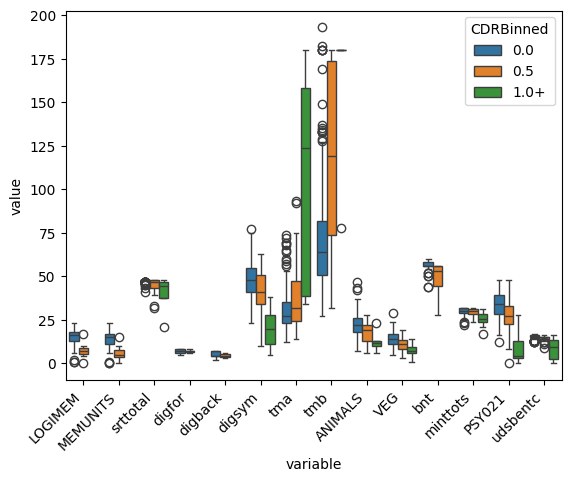

In [21]:
# PLOT INDVL ASSESSMENTS
# -------------

pdata = master_oasis.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

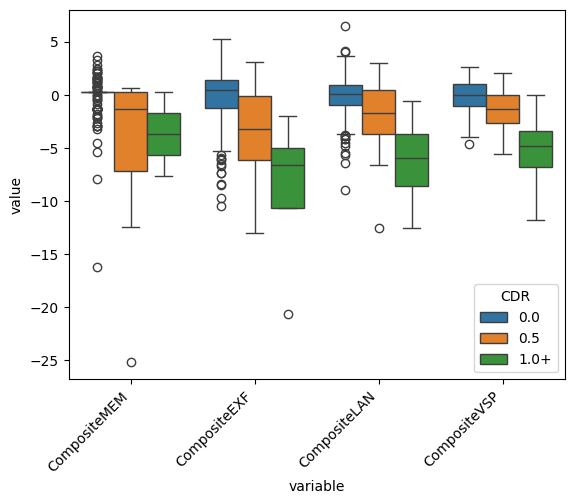

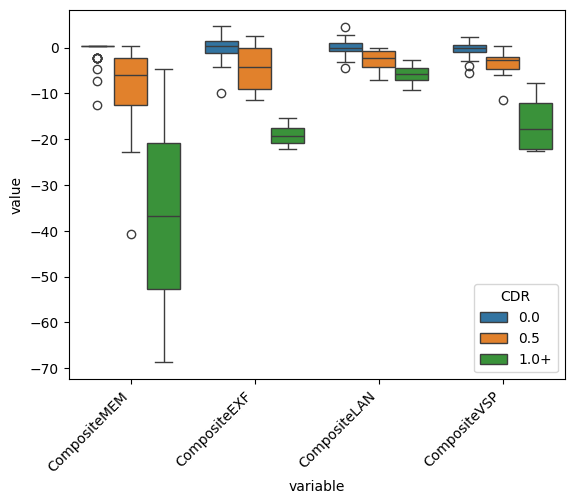

In [22]:
# COMPUTE COMPOSITES
# -------------

mem_cols = ['LOGIMEM', 'MEMUNITS', 'srttotal']
mem_higher_better = [True, True, True]
exf_cols = ['digfor', 'digback', 'digsym', 'tma', 'tmb']
exf_higher_better = [True, True, True, False, False]
lan_cols = ['ANIMALS', 'VEG', 'bnt', 'minttots']
lan_higher_better = [True, True, True, True]
vsp_cols = ['PSY021', 'udsbentc']
vsp_higher_better = [True, True]

master_oasis_train = master_oasis[master_oasis['Split'].str.contains('Training')].copy()
master_oasis_validation = master_oasis[master_oasis['Split'].str.contains('Validation')].copy()

result_train = nps_composites(
    data=master_oasis_train,
    cn_mask=master_oasis_train['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

result_validation = nps_composites(
    data=master_oasis_validation,
    cn_mask=master_oasis_validation['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

oasis_nps = pd.concat([result_train, result_validation], axis=0, ignore_index=True)

# SCAN

In [23]:
naccsub = pd.read_csv(path_scan_dataset)

naccsub['Date'] = pd.to_datetime(
        {'year': naccsub['VISITYR'],
        'month': naccsub['VISITMO'],
        'day': naccsub['VISITDAY']}
    )

# There are more assessments, but there are tons of missing data
# So only including the ones where there is a reasonable amount
assessments = [
    # MEMORY

    # EXF
    'DIGFORCT',
    'DIGBACCT',
    'TRAILA',
    'TRAILB',

    # LAN
    'ANIMALS',
    'VEG',
    'MINTTOTS',

    # VSP
    'UDSBENTC'
]

master_scan = master[master['DataSet'].eq("SCAN")].copy()
master_scan = add_features_by_date(master_scan, naccsub, fields=assessments,
                                   a_subject='Subject', a_date='TauAmyloidMeanDate',
                                   b_subject='NACCID', b_date='Date', include_gap_cols=False)

acceptable_values = {
    'DIGFORCT': (0, 14),
    'DIGBACCT': (0, 14),
    'TRAILA': (0, 150),
    'TRAILB': (0, 300),
    'ANIMALS': (0, 77),
    'VEG': (0, 77),
    'MINTTOTS': (0,32),
    'UDSBENTC': (0, 17)
}

# handle recoding of values
for col in assessments:
    lo, hi = acceptable_values[col]
    master_scan.loc[~master_scan[col].between(lo, hi, inclusive='both'), col] = np.nan

/tmp/ipykernel_2025479/1369534394.py:1: DtypeWarning: Columns (20,22,24,26,28,41,44,46,48,51,61,63,65,67,69,71,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,156,165,176,189,217,248,250,254,260,262,264,268,270,397,399,401,419,421,423,432,445,454,494,574,605,613,638,674,690,707,710,744,804,809,810,811,812,833,835,843,904,959) have mixed types. Specify dtype option on import or set low_memory=False.
  naccsub = pd.read_csv(path_scan_dataset)


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'DIGFORCT'),
  Text(1, 0, 'DIGBACCT'),
  Text(2, 0, 'TRAILA'),
  Text(3, 0, 'TRAILB'),
  Text(4, 0, 'ANIMALS'),
  Text(5, 0, 'VEG'),
  Text(6, 0, 'MINTTOTS'),
  Text(7, 0, 'UDSBENTC')])

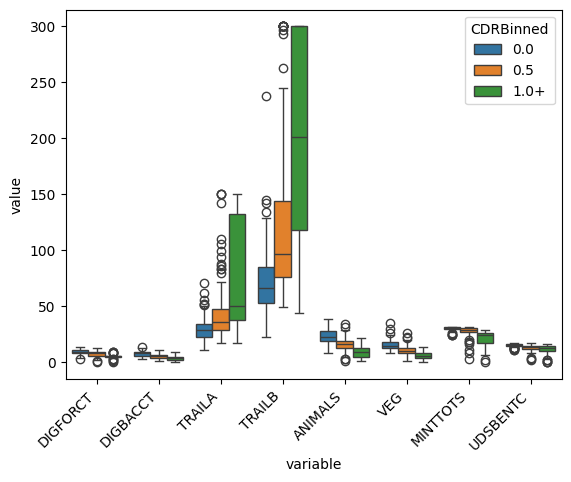

In [24]:
# PLOT INDVL ASSESSMENTS
# -------------

pdata = master_scan.melt(id_vars='CDRBinned', value_vars=assessments)
sns.boxplot(data=pdata, x='variable', y='value', hue='CDRBinned')
plt.xticks(rotation=45, ha='right')

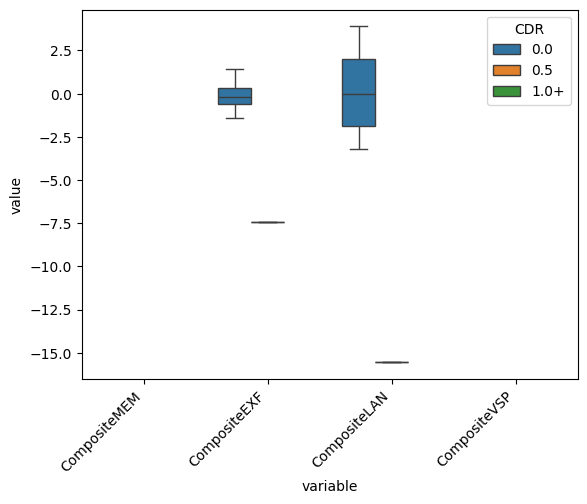

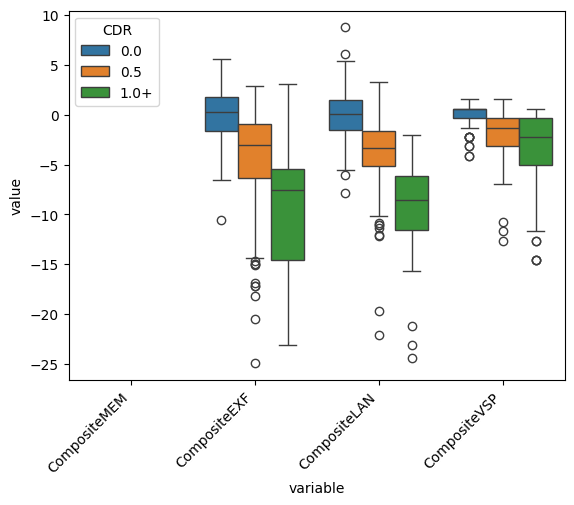

In [25]:
# COMPUTE COMPOSITES
# -------------

mem_cols = None
mem_higher_better = None
exf_cols = ['DIGFORCT', 'DIGBACCT', 'TRAILA', 'TRAILB']
exf_higher_better = [True, True, False, False]
lan_cols = ['ANIMALS', 'VEG', 'MINTTOTS']
lan_higher_better = [True, True, True]
vsp_cols = ['UDSBENTC']
vsp_higher_better = [True]

master_scan_train = master_scan[master_scan['Split'].str.contains('Training')].copy()
master_scan_validation = master_scan[master_scan['Split'].str.contains('Validation')].copy()

result_train = nps_composites(
    data=master_scan_train,
    cn_mask=master_scan_train['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

result_validation = nps_composites(
    data=master_scan_validation,
    cn_mask=master_scan_validation['ControlForStaging'],
    mem_cols=mem_cols,
    mem_higher_better=mem_higher_better,
    exf_cols=exf_cols,
    exf_higher_better=exf_higher_better,
    lan_cols=lan_cols,
    lan_higher_better=lan_higher_better,
    vsp_cols=vsp_cols,
    vsp_higher_better=vsp_higher_better,
)

scan_nps = pd.concat([result_train, result_validation], axis=0, ignore_index=True)

# Final join

In [72]:
all_nps = pd.concat([a4_nps, adni_nps, gs1_nps, gs2_nps, habs_nps, habshd_nps, oasis_nps, scan_nps], axis=0, ignore_index=True)

# SAVE!
root_output = get('output_directory')
opath = os.path.join(root_output, 'masterTables', 'FEATURE_NPS.csv')
all_nps.to_csv(opath, index=False)

# save a version for R
df = load_split(None, None)
opath = os.path.join(root_output, 'filesForR', 'master_with_nps.csv')
df.to_csv(opath, index=False)

/tmp/ipykernel_2025479/495203999.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_nps = pd.concat([a4_nps, adni_nps, gs1_nps, gs2_nps, habs_nps, habshd_nps, oasis_nps, scan_nps], axis=0, ignore_index=True)



* Loading master dataframe
    + Loading base from /scratch/tom.earnest/atstaging/masterTables/MASTER.csv
    + Complete.
* Applying filters.
    + Filters found: ['FILTER_QC.csv', 'FILTER_SPLIT.csv', 'FILTER_STAGING.csv']
    + Applying filter: FILTER_QC.csv
    + # Records before: 5811; after: 5590
    + Applying filter: FILTER_SPLIT.csv
    + # Records before: 5590; after: 4515
    + Applying filter: FILTER_STAGING.csv
    + # Records before: 4515; after: 4515
    + Complete
* Adding features.
    + Features found: ['FEATURE_AA2024Biological.csv', 'FEATURE_AA2024Clinical.csv', 'FEATURE_AMYLOIDPETNET.csv', 'FEATURE_AMYLOIDSTATUS.csv', 'FEATURE_COVARIATES.csv', 'FEATURE_ICV.csv', 'FEATURE_MMSE.csv', 'FEATURE_NMFLOADINGS.csv', 'FEATURE_NPS.csv', 'FEATURE_SPLIT.csv', 'FEATURE_STAGING.csv', 'FEATURE_SUSTAIN.csv', 'FEATURE_TAUSTATUS.csv', 'FEATURE_WSCORES.csv']
    + Adding features: FEATURE_AA2024Biological.csv
    + # Features before: 20; after: 21 (nrows: 4515)
    + Adding features: 